In [8]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../warehouse/payments_warehouse.db")

query = """
SELECT d.full_date, SUM(f.amount_inr) AS daily_tpv, COUNT(*) AS txn_count
FROM fact_transactions f
JOIN dim_date d ON f.date_key = d.date_key
GROUP BY d.full_date
ORDER BY d.full_date;
"""

ts = pd.read_sql(query, conn)
ts["full_date"] = pd.to_datetime(ts["full_date"])
ts = ts.set_index("full_date")
ts = ts.asfreq("D")

ts.head()

,daily_tpv,txn_count
full_date,,
2024-01-01,881371,665
2024-01-02,896546,707
2024-01-03,868891,638
2024-01-04,820257,661
2024-01-05,931644,705


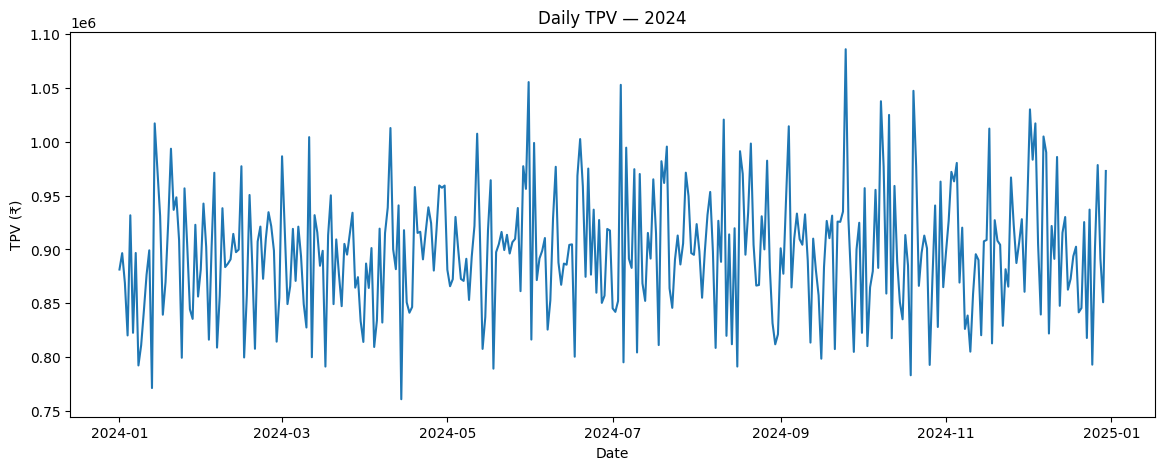

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(ts.index, ts["daily_tpv"])
plt.title("Daily TPV — 2024")
plt.xlabel("Date")
plt.ylabel("TPV (₹)")
plt.show()

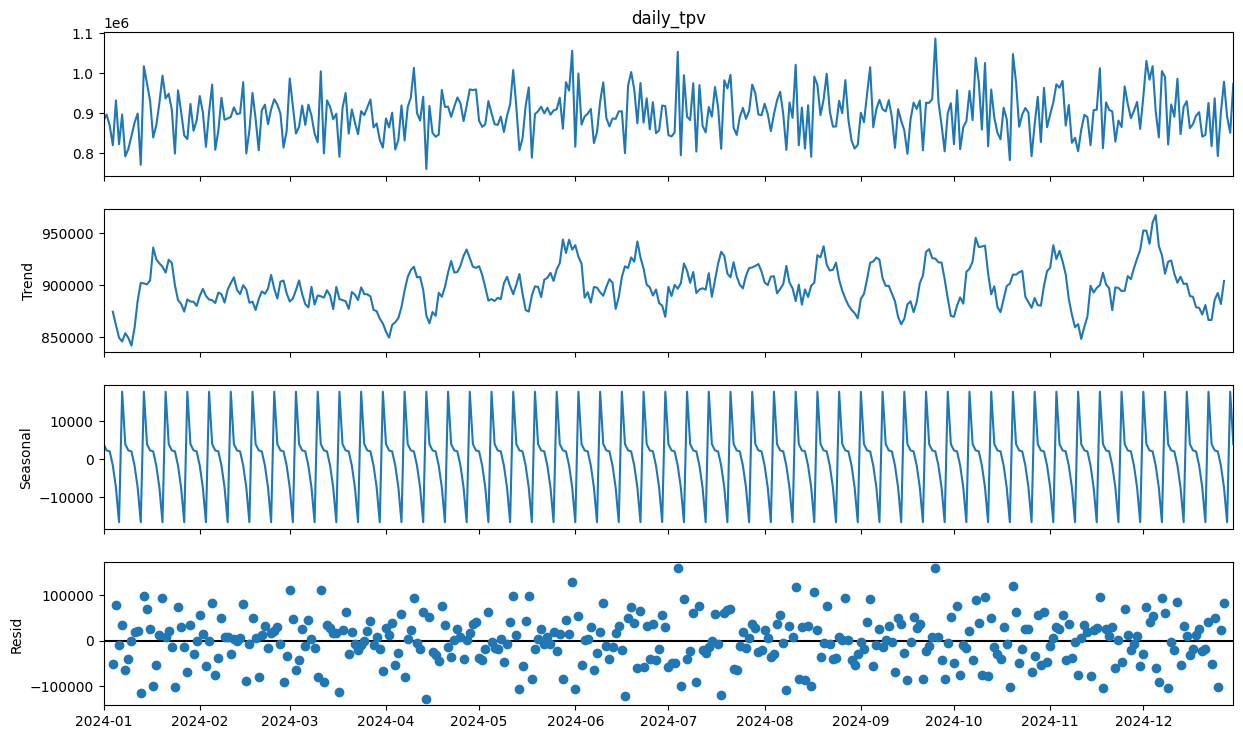

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(ts["daily_tpv"], model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["daily_tpv"])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -20.0502
p-value: 0.0000
Critical Values:
   1%: -3.4484
   5%: -2.8695
   10%: -2.5710


In [11]:
train = ts.iloc[:-30]   # all but last 30 days
test = ts.iloc[-30:]    # last 30 days held out

print(train.shape, test.shape)

(335, 2) (30, 2)


In [13]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(train["daily_tpv"], order=(2,0,2))
fit_arima = model_arima.fit()

C:\Users\suraj\Documents\CODING RELATED STUFF\Data Analyst\upi-intelligence\venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [14]:
print(fit_arima.summary())

                               SARIMAX Results                                
Dep. Variable:              daily_tpv   No. Observations:                  335
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -4136.259
Date:                Thu, 23 Jul 2026   AIC                           8284.517
Time:                        01:58:06   BIC                           8307.402
Sample:                    01-01-2024   HQIC                          8293.641
                         - 11-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       8.974e+05   2249.265    398.973      0.000    8.93e+05    9.02e+05
ar.L1         -0.1820      0.183     -0.996      0.319      -0.540       0.176
ar.L2          0.8128      0.183      4.447      0.0

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(
    train["daily_tpv"],
    order=(2,0,2),
    seasonal_order=(1,1,1,7)
)
fit_sarima = model_sarima.fit(disp=False)

In [16]:
print(fit_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                           daily_tpv   No. Observations:                  335
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 7)   Log Likelihood               -4134.247
Date:                             Thu, 23 Jul 2026   AIC                           8282.494
Time:                                     01:58:50   BIC                           8309.045
Sample:                                 01-01-2024   HQIC                          8293.087
                                      - 11-30-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.6124      0.051    -31.806      0.000      -1.712      -1.513
ar.L2         -0.7638      

In [17]:
forecast_arima = fit_arima.forecast(steps=30)
forecast_sarima = fit_sarima.forecast(steps=30)

comparison = pd.DataFrame({
    "actual": test["daily_tpv"],
    "arima_forecast": forecast_arima.values,
    "sarima_forecast": forecast_sarima.values
})
comparison

,actual,arima_forecast,sarima_forecast
full_date,,,
2024-12-01,940653,905581.932338,903232.692734
2024-12-02,1029843,889149.893190,942953.205806
2024-12-03,983201,905550.244536,920158.018046
2024-12-04,1016857,889210.150251,899943.003967
2024-12-05,904849,905513.524572,898003.858509
2024-12-06,839645,889265.808571,921882.588587
2024-12-07,1004722,905473.551240,853370.409685
2024-12-08,989887,889318.321008,898058.022297
2024-12-09,822042,905431.505984,947994.545714


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(comparison["actual"], comparison["arima_forecast"]))
mae_arima = mean_absolute_error(comparison["actual"], comparison["arima_forecast"])

rmse_sarima = np.sqrt(mean_squared_error(comparison["actual"], comparison["sarima_forecast"]))
mae_sarima = mean_absolute_error(comparison["actual"], comparison["sarima_forecast"])

print(f"ARIMA  -> RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}")
print(f"SARIMA -> RMSE: {rmse_sarima:.2f}, MAE: {mae_sarima:.2f}")

ARIMA  -> RMSE: 66944.75, MAE: 54845.15
SARIMA -> RMSE: 71407.13, MAE: 57340.48


In [19]:
naive_forecast = np.full(30, train["daily_tpv"].mean())

rmse_naive = np.sqrt(mean_squared_error(test["daily_tpv"], naive_forecast))
mae_naive = mean_absolute_error(test["daily_tpv"], naive_forecast)

print(f"Naive (mean) -> RMSE: {rmse_naive:.2f}, MAE: {mae_naive:.2f}")

Naive (mean) -> RMSE: 64310.54, MAE: 52696.53


In [20]:
from prophet import Prophet

train_prophet = train.reset_index().rename(columns={"full_date": "ds", "daily_tpv": "y"})[["ds", "y"]]
test_prophet = test.reset_index().rename(columns={"full_date": "ds", "daily_tpv": "y"})[["ds", "y"]]

train_prophet.head()

,ds,y
0,2024-01-01,881371
1,2024-01-02,896546
2,2024-01-03,868891
3,2024-01-04,820257
4,2024-01-05,931644


In [21]:
model_prophet = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)
fit_prophet = model_prophet.fit(train_prophet)

02:02:49 - cmdstanpy - INFO - Chain [1] start processing
02:02:49 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future = model_prophet.make_future_dataframe(periods=30)
forecast_prophet = fit_prophet.predict(future)

# Pull out just the forecasted period, matching your test set's dates
prophet_forecast_values = forecast_prophet.set_index("ds").loc[test_prophet["ds"], "yhat"]
prophet_forecast_values

ds
2024-12-01    916234.608783
2024-12-02    906586.735356
2024-12-03    901418.910922
2024-12-04    903219.130246
2024-12-05    897032.232070
2024-12-06    894890.075093
2024-12-07    882051.465762
2024-12-08    916157.396654
2024-12-09    906509.523227
2024-12-10    901341.698793
2024-12-11    903141.918118
2024-12-12    896955.019942
2024-12-13    894812.862964
2024-12-14    881974.253634
2024-12-15    916080.184526
2024-12-16    906432.311099
2024-12-17    901264.486665
2024-12-18    903064.705989
2024-12-19    896877.807813
2024-12-20    894735.650836
2024-12-21    881897.041505
2024-12-22    916002.972397
2024-12-23    906355.098970
2024-12-24    901187.274536
2024-12-25    902987.493861
2024-12-26    896800.595685
2024-12-27    894658.438707
2024-12-28    881819.829377
2024-12-29    915925.760269
2024-12-30    906277.886842
Name: yhat, dtype: float64

In [23]:
comparison["prophet_forecast"] = prophet_forecast_values.values

rmse_prophet = np.sqrt(mean_squared_error(comparison["actual"], comparison["prophet_forecast"]))
mae_prophet = mean_absolute_error(comparison["actual"], comparison["prophet_forecast"])

print(f"Naive    -> RMSE: {rmse_naive:.2f}, MAE: {mae_naive:.2f}")
print(f"ARIMA    -> RMSE: {rmse_arima:.2f}, MAE: {mae_arima:.2f}")
print(f"SARIMA   -> RMSE: {rmse_sarima:.2f}, MAE: {mae_sarima:.2f}")
print(f"Prophet  -> RMSE: {rmse_prophet:.2f}, MAE: {mae_prophet:.2f}")

Naive    -> RMSE: 64310.54, MAE: 52696.53
ARIMA    -> RMSE: 66944.75, MAE: 54845.15
SARIMA   -> RMSE: 71407.13, MAE: 57340.48
Prophet  -> RMSE: 63786.32, MAE: 51741.92


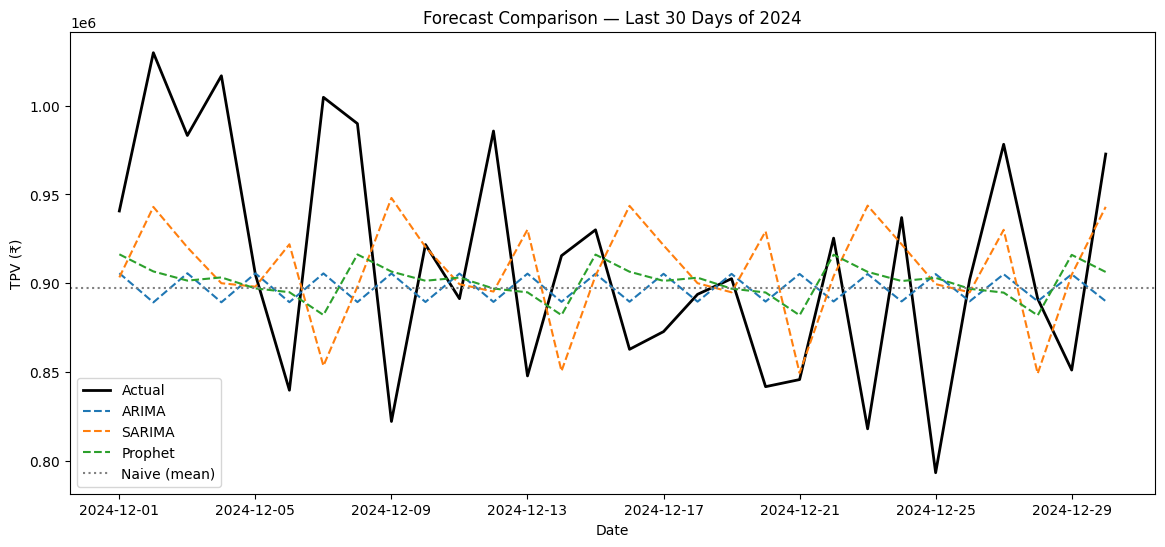

In [24]:
plt.figure(figsize=(14,6))
plt.plot(comparison.index, comparison["actual"], label="Actual", linewidth=2, color="black")
plt.plot(comparison.index, comparison["arima_forecast"], label="ARIMA", linestyle="--")
plt.plot(comparison.index, comparison["sarima_forecast"], label="SARIMA", linestyle="--")
plt.plot(comparison.index, comparison["prophet_forecast"], label="Prophet", linestyle="--")
plt.axhline(y=train["daily_tpv"].mean(), label="Naive (mean)", linestyle=":", color="gray")
plt.legend()
plt.title("Forecast Comparison — Last 30 Days of 2024")
plt.xlabel("Date")
plt.ylabel("TPV (₹)")
plt.show()

In [26]:
model_comparison = pd.DataFrame({
    "model": ["Naive (mean)", "ARIMA(2,0,2)", "SARIMA(2,0,2)x(1,1,1,7)", "Prophet"],
    "RMSE": [rmse_naive, rmse_arima, rmse_sarima, rmse_prophet],
    "MAE": [mae_naive, mae_arima, mae_sarima, mae_prophet]
})
model_comparison.to_csv("../reports/forecast_model_comparison.csv", index=False)
model_comparison

,model,RMSE,MAE
0,Naive (mean),64310.541408,52696.529055
1,"ARIMA(2,0,2)",66944.745923,54845.148227
2,"SARIMA(2,0,2)x(1,1,1,7)",71407.127667,57340.482704
3,Prophet,63786.322045,51741.916218
